# Extent-rule arm with the new MTM extent law (Fusion_PhD-bhx7.14)

User, 2026-10-08: "ok go ahead and Rerun the GFTM extent-rule arm with the new law on the NSTX hypercubes".

**Arms.** `law2 rule` = `extent_rule_tf035_law2`: the `extent_rule_tf035` arm with only the extent law changed, from $\theta_{95} = 9.46\,k_y^{-0.351}\hat s^{-0.527}$ to the `bhx7.13` refit $16.30\,k_y^{-0.285}\hat s^{-0.593}q^{-0.355}$ ($\pi$, full span; one-sided extent = half). Per case NXGRID $=\arg\min_n|R(n)-\text{extent}/0.35\pi|$ on $[14,65]$, NBASIS $=$ NXGRID$-6$, WIDTH $=$ extent$/x_{max}$(NXGRID). Cases with $R>78.658$ are not built. `law2 maxbasis` = `extent_maxbasis_law2_s100` (director scope addition, user 2026-10-08): `extent_maxbasis_s100` with the new law, NXGRID 65, NBASIS 59, WIDTH = new-law one-sided reach$/x_{max}(65)$, every case built. Compared against `rule (9.46 law)` (`extent_rule_tf035`), `m11_new`, `rule s=1.41` (`extent_rule_tf035_s141`) the max-basis arms (`extent_maxbasis_s141`, and `_s100` on n1000) and `fw174` (`gftm_fw174`, default WIDTH 1.74, NXGRID 128 requested). These feed the README's recommended MTM settings.

**Population and scoring** as `mtm_only_rescore` (`docs/mode_filtering.md`): GS2 $\gamma>10^{-3}$ and the classifier labels the GS2 dominant mode MTM. GFTM is never filtered; its dominant mode (argmax $\gamma$) is scored whatever its type. Capture = that mode has $T>0.15$ and $\omega<0$. A non-MTM dominant mode is a capture failure whose error still counts. No unstable mode is a MISS ($+\infty$).

**Pairing.** The headline table is on the cases every compared arm built (the paired set). A second table keeps the full MTM population and counts a case an arm could not build as a miss, as `mtm_only_rescore` did.

## Imports and settings

In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
import xarray as xr
from pyrokinetics import PyroHypercube
from pyrokinetics.diagnostics.field_line import FieldLine
from general_analysis import mode_classification as mc
from general_analysis.mode_classification import T_TEAR

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file() and (p / "notebooks").is_dir())
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
plt.rcParams.update({"axes.titlesize": 16, "axes.labelsize": 16, "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 12})
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "mtm_extent_rule_law2"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
base = data_root / "GFTM/Runs/LATIN_HYPERCUBE/NSTX_MTM"
gs2_base = data_root / "GS2/Runs/LATIN_HYPERCUBE/NSTX_MTM"

arms_all = {   # label -> leaf
    "law2 rule": "extent_rule_tf035_law2",
    "law2 maxbasis": "extent_maxbasis_law2_s100",
    "rule (9.46 law)": "extent_rule_tf035",
    "m11_new": "m11_new",
    "rule s=1.41": "extent_rule_tf035_s141",
    "maxbasis s=1.41": "extent_maxbasis_s141",
    "maxbasis s=1": "extent_maxbasis_s100",
    "fw174": "gftm_fw174",
}
draws = {"n1000": ("beta_q_shat_ky_n1000", list(arms_all)),
         "n300":  ("beta_q_shat_ky_n300", [a for a in arms_all if a != "maxbasis s=1"])}
NEW, NEWMB, OLD, M11 = "law2 rule", "law2 maxbasis", "rule (9.46 law)", "m11_new"
gs2_unstable = 1e-3
n_boot, seed = 2000, 0

## Load

Per draw: the GS2 tail-averaged cube (`pyro_cube_avg`) and its classifier label, and every GFTM arm's dominant-mode $\gamma$, $\omega$, $T$ (pyro `FieldLine` with each sample's own $dl$: the `tearing_parameter` GyroRun stored, or the same `FieldLine` call on `sample_pyro(i)` for a legacy cube that has none). Mode 0 is the dominant mode (IBRANCH=-1, asserted). NBASIS / NXGRID per sample from the scan: `parameter_dict` where scanned, the legacy cubes' audited `nbasis_used` / `nxgrid_used` coordinate, otherwise the scan's base deck. Three maxbasis leaves record the template 12 / 128 there although every deck ran 59 / 65; they are overridden explicitly (Fusion_PhD-476z).

In [2]:
gs2_scans, gftm_scans = {}, {}
for dname, (draw, arms) in draws.items():
    gs2_dir = gs2_base / draw / "pyro_cube_avg"
    gs2_scans[dname] = PyroHypercube(pyroscan_json=gs2_dir / "pyroscan.json", load_base_pyro=True)
    mc.attach_legacy_funcs(gs2_scans[dname])   # this json predates parameter_func serialisation: re-attach beta -> beta_prime
    gs2_scans[dname].load_gk_output(netcdf_file=gs2_dir / "cube.nc")
    for arm in arms:
        leaf_dir = base / draw / arms_all[arm]
        if (leaf_dir / "pyro_cube").is_dir():   # legacy leaf
            gftm_scans[dname, arm] = PyroHypercube(pyroscan_json=leaf_dir / "pyro_cube/pyroscan.json", load_base_pyro=True)
            gftm_scans[dname, arm].load_gk_output(netcdf_file=leaf_dir / "pyro_cube/cube.nc")
        else:   # GyroRun leaf
            gftm_scans[dname, arm] = PyroHypercube(pyroscan_json=leaf_dir / "pyroscan.json", load_base_pyro=True)
            gftm_scans[dname, arm].load_gk_output(netcdf_file=leaf_dir / "pyroscan.nc")

In [3]:
# These scans record the template NBASIS 12 / NXGRID 128 although every input.gftm.gen ran 59 / 65 (Fusion_PhD-476z)
scan_settings_wrong = {("beta_q_shat_ky_n300", "extent_maxbasis_s141"), ("beta_q_shat_ky_n300", "extent_maxbasis_law2_s100"),
                       ("beta_q_shat_ky_n1000", "extent_maxbasis_law2_s100")}

results = {}
for dname, (draw, arms) in draws.items():
    gs2_output = gs2_scans[dname].gk_output.data
    names = [str(name) for name in gs2_output.sample_name.values]
    gamma_gs2 = np.asarray(gs2_output.growth_rate.values, float).reshape(len(names), -1)[:, 0]
    unstable = gamma_gs2 > gs2_unstable
    label = np.where(unstable, mc.classify(mc.indicators(gs2_scans[dname], gs2_output)), "").astype(object)
    draw_result = dict(names=names, gamma_gs2=gamma_gs2, unstable=unstable, label=label, mtm=unstable & (label == "MTM"), arm={},
                       unit=f"{gs2_output.growth_rate.data.units:~P}")
    for arm in arms:
        gftm_scan, leaf = gftm_scans[dname, arm], arms_all[arm]
        gftm_output = gftm_scan.gk_output.data
        # IBRANCH=-1: modes come sorted by growth rate, so mode 0 is the dominant mode
        assert (gftm_output.growth_rate.pint.dequantify().fillna(-np.inf).argmax("mode") == 0).all()
        row = {str(name): i for i, name in enumerate(gftm_output.sample_name.values)}
        take = np.array([row.get(name, -1) for name in names])
        have, idx = take >= 0, np.maximum(take, 0)
        if "tearing_parameter" in gftm_output:   # GyroRun leaf: pyro's FieldLine T, stored at save time
            tearing = np.asarray(gftm_output.tearing_parameter.isel(kx=0, drop=True, missing_dims="ignore").transpose("sample", "mode").values, float)
        else:   # legacy cube: the same pyro FieldLine T, on each sample's own geometry (sample_pyro), only where needed
            apar = gftm_output.eigenfunctions.sel(field="apar").pint.dequantify()
            tearing = np.full((gftm_output.sizes["sample"], gftm_output.sizes["mode"]), np.nan)
            for i in take[have]:
                pyro = gftm_scan.sample_pyro(i, gk_output=xr.Dataset({"apar": apar.isel(sample=i, drop=True)}))
                tearing[i] = np.asarray(FieldLine(pyro).compute_linear_tearing_parameter(), float).ravel()
        settings = {}
        for key, used in (("NBASIS_MAX", "nbasis_used"), ("NXGRID", "nxgrid_used")):
            if key in gftm_scan.parameter_dict:
                settings[key] = np.asarray(gftm_scan.parameter_dict[key], float)
            elif used in gftm_output.coords:   # legacy cube: audited from out.gftm.localdump
                settings[key] = np.asarray(gftm_output[used].values, float)
            elif (draw, leaf) in scan_settings_wrong:
                settings[key] = np.full(gftm_output.sizes["sample"], {"NBASIS_MAX": 59.0, "NXGRID": 65.0}[key])
            else:   # one value for every sample, in the scan's base deck
                settings[key] = np.full(gftm_output.sizes["sample"], float(gftm_scan.base_pyro.gk_input.data[key.lower()]))
        dominant = lambda values: np.where(have, np.asarray(values, float)[:, 0][idx], np.nan)
        per_case = lambda values: np.where(have, values[idx], np.nan)
        arm_result = dict(have=have,
                          gamma=dominant(gftm_output.growth_rate.transpose("sample", "mode").values),
                          omega=dominant(gftm_output.mode_frequency.transpose("sample", "mode").values),
                          T=dominant(tearing), nbasis=per_case(settings["NBASIS_MAX"]), nxgrid=per_case(settings["NXGRID"]))
        arm_result["mtm_mode"] = arm_result["have"] & (arm_result["gamma"] > 0) & (arm_result["omega"] < 0) & (arm_result["T"] > T_TEAR)
        draw_result["arm"][arm] = arm_result
        print(dname, arm, "samples in cube", gftm_output.sizes["sample"], "matched", int(have.sum()), "| gamma units GFTM", gftm_output.growth_rate.data.units, "GS2", draw_result["unit"])
    results[dname] = draw_result
    unstable_labels = label[unstable]
    n_mtm = int(draw_result["mtm"].sum())
    print(f"{dname}: {len(names)} cases | GS2-stable {len(names) - unstable.sum()} | KBM {int((unstable_labels == 'KBM').sum())} | "
          f"mixed {int((unstable_labels == 'mixed').sum())} | MTM kept {n_mtm} | removed {len(names) - n_mtm}")

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_0b1e/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_0b1e/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_0b1e/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


n1000 law2 rule samples in cube 986 matched 986 | gamma units GFTM vref_nrl / lref_minor_radius GS2 vref_nrl/lref_minor_radius
n1000 law2 maxbasis samples in cube 1000 matched 1000 | gamma units GFTM vref_nrl / lref_minor_radius GS2 vref_nrl/lref_minor_radius


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_0b1e/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


n1000 rule (9.46 law) samples in cube 990 matched 990 | gamma units GFTM vref_nrl / lref_minor_radius GS2 vref_nrl/lref_minor_radius


...

n300 m11_new samples in cube 300 matched 300 | gamma units GFTM vref_nrl / lref_minor_radius GS2 vref_nrl/lref_minor_radius


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_0b1e/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_0b1e/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


n300 rule s=1.41 samples in cube 297 matched 297 | gamma units GFTM vref_nrl / lref_minor_radius GS2 vref_nrl/lref_minor_radius
n300 maxbasis s=1.41 samples in cube 300 matched 300 | gamma units GFTM vref_nrl / lref_minor_radius GS2 vref_nrl/lref_minor_radius


n300 fw174 samples in cube 300 matched 300 | gamma units GFTM vref_nrl / lref_minor_radius GS2 vref_nrl/lref_minor_radius
n300: 300 cases | GS2-stable 31 | KBM 37 | mixed 23 | MTM kept 209 | removed 91


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_0b1e/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Built, infeasible and floored cases

Infeasible = no deck (the rule's $R>78.658$ wall). Floored = NXGRID at the floor 14 (finer $\theta_{first}$ than asked; the extent is still exact).

In [4]:
for dname, draw_result in results.items():
    n_cases, mtm = len(draw_result["names"]), draw_result["mtm"]
    for arm in (NEW, OLD):
        arm_result = draw_result["arm"][arm]
        floored = arm_result["nxgrid"] == 14
        print(f"{dname} {arm:16s}: infeasible {int((~arm_result['have']).sum())} of {n_cases} ({int((~arm_result['have'] & mtm).sum())} in the MTM population); "
              f"floored {int((floored & arm_result['have']).sum())} of {int(arm_result['have'].sum())}; "
              f"NBASIS min/median/max {np.nanmin(arm_result['nbasis']):.0f}/{np.nanmedian(arm_result['nbasis']):.0f}/{np.nanmax(arm_result['nbasis']):.0f}")
    built_new, built_old = draw_result["arm"][NEW]["have"], draw_result["arm"][OLD]["have"]
    print(f"{dname}: infeasible in both {int((~built_new & ~built_old).sum())}; new only {int((~built_new & built_old).sum())}; "
          f"old only {int((built_new & ~built_old).sum())}")

n1000 law2 rule       : infeasible 14 of 1000 (11 in the MTM population); floored 345 of 986; NBASIS min/median/max 8/11/59
n1000 rule (9.46 law) : infeasible 10 of 1000 (9 in the MTM population); floored 389 of 990; NBASIS min/median/max 8/11/58
n1000: infeasible in both 8; new only 6; old only 2
n300 law2 rule       : infeasible 4 of 300 (3 in the MTM population); floored 100 of 296; NBASIS min/median/max 8/12/56
n300 rule (9.46 law) : infeasible 3 of 300 (3 in the MTM population); floored 120 of 297; NBASIS min/median/max 8/10/56
n300: infeasible in both 3; new only 1; old only 0


## Score

medlog = median $|\log_{10}(\gamma_{GFTM}/\gamma_{GS2})|$, medAE = median $|\gamma_{GFTM}-\gamma_{GS2}|$ (LogMed = $\log_{10}$ medAE), both on the dominant mode with misses $+\infty$. 95% bootstrap intervals on the same resampled cases for every arm. Paired: McNemar exact test (binomial on the discordant captures) of `law2 rule` and of `law2 maxbasis` against every other arm (the bead's pair: old-law rule and `m11_new`; for `law2 maxbasis` the matching old arm is `maxbasis s=1`), and the bootstrap interval of the paired medlog difference.

In [5]:
def errors(draw_result, arm):
    arm_result = draw_result["arm"][arm]
    positive = arm_result["have"] & (arm_result["gamma"] > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        log_error = np.where(positive, np.abs(np.log10(arm_result["gamma"] / draw_result["gamma_gs2"])), np.inf)
    abs_error = np.where(positive, np.abs(arm_result["gamma"] - draw_result["gamma_gs2"]), np.inf)
    return log_error, abs_error, arm_result["mtm_mode"], ~positive

rng = np.random.default_rng(seed)
def table(draw_result, arms, mask):
    n_cases = int(mask.sum())
    boot_idx = rng.integers(0, n_cases, (n_boot, n_cases))
    out = {}
    for arm in arms:
        log_error, abs_error, captured, miss = (values[mask] for values in errors(draw_result, arm))
        out[arm] = dict(n=n_cases, medlog=np.median(log_error), ci=np.percentile(np.median(log_error[boot_idx], axis=1), [2.5, 97.5]),
                        medae=np.median(abs_error), ae_ci=np.percentile(np.median(abs_error[boot_idx], axis=1), [2.5, 97.5]),
                        capture=captured.mean(), cap_ci=np.percentile(captured[boot_idx].mean(axis=1), [2.5, 97.5]),
                        capfail=int((~captured & ~miss).sum()), misses=int(miss.sum()),
                        nbasis=np.nanmedian(draw_result["arm"][arm]["nbasis"][mask]))
    return out, boot_idx

def paired(draw_result, arm_x, arm_y, mask, boot_idx):
    log_error_x, _, captured_x, _ = (v[mask] for v in errors(draw_result, arm_x))
    log_error_y, _, captured_y, _ = (v[mask] for v in errors(draw_result, arm_y))
    n_y_only, n_x_only = int((~captured_x & captured_y).sum()), int((captured_x & ~captured_y).sum())   # y only, x only
    p_value = binomtest(min(n_y_only, n_x_only), n_y_only + n_x_only, 0.5).pvalue if n_y_only + n_x_only else 1.0
    boot_dmed = np.median(log_error_x[boot_idx], axis=1) - np.median(log_error_y[boot_idx], axis=1)
    return dict(x_only=n_x_only, y_only=n_y_only, p=p_value, dmed=np.median(log_error_x) - np.median(log_error_y), dci=np.percentile(boot_dmed, [2.5, 97.5]))

table_paired, table_full, pairs = {}, {}, {}
for dname, draw_result in results.items():
    arms = draws[dname][1]
    paired_mask = draw_result["mtm"] & np.logical_and.reduce([draw_result["arm"][arm]["have"] for arm in arms])
    table_paired[dname], boot_idx = table(draw_result, arms, paired_mask)
    pairs[dname] = {(arm_x, arm_y): paired(draw_result, arm_x, arm_y, paired_mask, boot_idx) for arm_x in (NEW, NEWMB) for arm_y in arms if arm_y != arm_x}
    table_full[dname], _ = table(draw_result, arms, draw_result["mtm"])
    print(f"\n{dname}: PAIRED MTM-only n={int(paired_mask.sum())} (MTM population {int(draw_result['mtm'].sum())}; dropped as unbuilt by some arm "
          f"{int(draw_result['mtm'].sum() - paired_mask.sum())})")
    print(f"{'arm':16s} medlog [95% CI] | medAE [CI] | capture [CI] | cap.fail | misses | med NBASIS")
    for arm in arms:
        arm_row = table_paired[dname][arm]
        print(f"{arm:16s} {arm_row['medlog']:.3f} [{arm_row['ci'][0]:.3f},{arm_row['ci'][1]:.3f}] | {arm_row['medae']:.4f} [{arm_row['ae_ci'][0]:.4f},{arm_row['ae_ci'][1]:.4f}] | "
              f"{arm_row['capture']:.3f} [{arm_row['cap_ci'][0]:.3f},{arm_row['cap_ci'][1]:.3f}] | {arm_row['capfail']:3d} | {arm_row['misses']:3d} | {arm_row['nbasis']:.0f}")
    print("x vs y:  captured by x only / by y only | McNemar p | medlog x - y [95% CI]")
    for (arm_x, arm_y), pair in pairs[dname].items():
        print(f"  {arm_x:14s} vs {arm_y:16s} {pair['x_only']:3d} / {pair['y_only']:3d} | p = {pair['p']:.3g} | {pair['dmed']:+.3f} [{pair['dci'][0]:+.3f},{pair['dci'][1]:+.3f}]")
    print(f"\n{dname}: FULL MTM-only n={int(draw_result['mtm'].sum())}, unbuilt = miss")
    for arm in arms:
        arm_row = table_full[dname][arm]
        print(f"{arm:16s} medlog {arm_row['medlog']:.3f} [{arm_row['ci'][0]:.3f},{arm_row['ci'][1]:.3f}] | medAE {arm_row['medae']:.4f} | capture {arm_row['capture']:.3f} "
              f"[{arm_row['cap_ci'][0]:.3f},{arm_row['cap_ci'][1]:.3f}] | misses {arm_row['misses']}")


n1000: PAIRED MTM-only n=698 (MTM population 711; dropped as unbuilt by some arm 13)
arm              medlog [95% CI] | medAE [CI] | capture [CI] | cap.fail | misses | med NBASIS
law2 rule        0.392 [0.353,0.426] | 0.1283 [0.1078,0.1477] | 0.781 [0.749,0.809] | 126 |  27 | 11
law2 maxbasis    0.347 [0.320,0.379] | 0.1298 [0.1145,0.1455] | 0.824 [0.795,0.850] | 122 |   1 | 59
rule (9.46 law)  0.401 [0.364,0.434] | 0.1414 [0.1185,0.1650] | 0.772 [0.741,0.804] | 135 |  24 | 10
m11_new          0.280 [0.249,0.321] | 0.0924 [0.0772,0.1136] | 0.728 [0.695,0.761] | 180 |  10 | 24
rule s=1.41      0.349 [0.321,0.383] | 0.1364 [0.1144,0.1481] | 0.798 [0.768,0.830] | 121 |  20 | 10
maxbasis s=1.41  0.317 [0.294,0.352] | 0.1216 [0.1056,0.1333] | 0.809 [0.779,0.838] | 129 |   4 | 59
maxbasis s=1     0.341 [0.309,0.361] | 0.1254 [0.1039,0.1390] | 0.821 [0.792,0.848] | 124 |   1 | 59
fw174            0.472 [0.435,0.533] | 0.0958 [0.0854,0.1131] | 0.507 [0.468,0.544] | 289 |  55 | 12
x vs y:  cap


n300: PAIRED MTM-only n=206 (MTM population 209; dropped as unbuilt by some arm 3)
arm              medlog [95% CI] | medAE [CI] | capture [CI] | cap.fail | misses | med NBASIS
law2 rule        0.366 [0.332,0.436] | 0.1133 [0.0855,0.1567] | 0.743 [0.684,0.801] |  43 |  10 | 12
law2 maxbasis    0.375 [0.309,0.418] | 0.1035 [0.0854,0.1285] | 0.874 [0.825,0.917] |  26 |   0 | 59
rule (9.46 law)  0.407 [0.360,0.453] | 0.1107 [0.0847,0.1378] | 0.733 [0.670,0.796] |  49 |   6 | 11
m11_new          0.273 [0.219,0.323] | 0.0913 [0.0555,0.1222] | 0.709 [0.646,0.767] |  55 |   5 | 24
rule s=1.41      0.390 [0.335,0.443] | 0.1255 [0.0910,0.1630] | 0.772 [0.714,0.830] |  41 |   6 | 11
maxbasis s=1.41  0.347 [0.311,0.384] | 0.1105 [0.0853,0.1395] | 0.835 [0.786,0.883] |  32 |   2 | 59
fw174            0.396 [0.360,0.513] | 0.0736 [0.0547,0.1043] | 0.471 [0.408,0.539] |  91 |  18 | 12
x vs y:  captured by x only / by y only | McNemar p | medlog x - y [95% CI]
  law2 rule      vs law2 maxbasis     1

## Plots

Figure 1: per database, LogMed $|\gamma_{GFTM}-\gamma_{GS2}|$ and capture for every arm on the paired MTM set, with 95% bootstrap bars. Figure 2: the low-level result behind it, $\gamma_{GFTM}$ against $\gamma_{GS2}$ for the old-law rule, the new-law rule and the new-law max-basis arm on the paired MTM set, captured cases filled and capture failures open. Counts and definitions are in the README.

/tmp/ipykernel_140489/2285894245.py:15: UserWarning: The figure layout has changed to tight
  fig1.tight_layout()


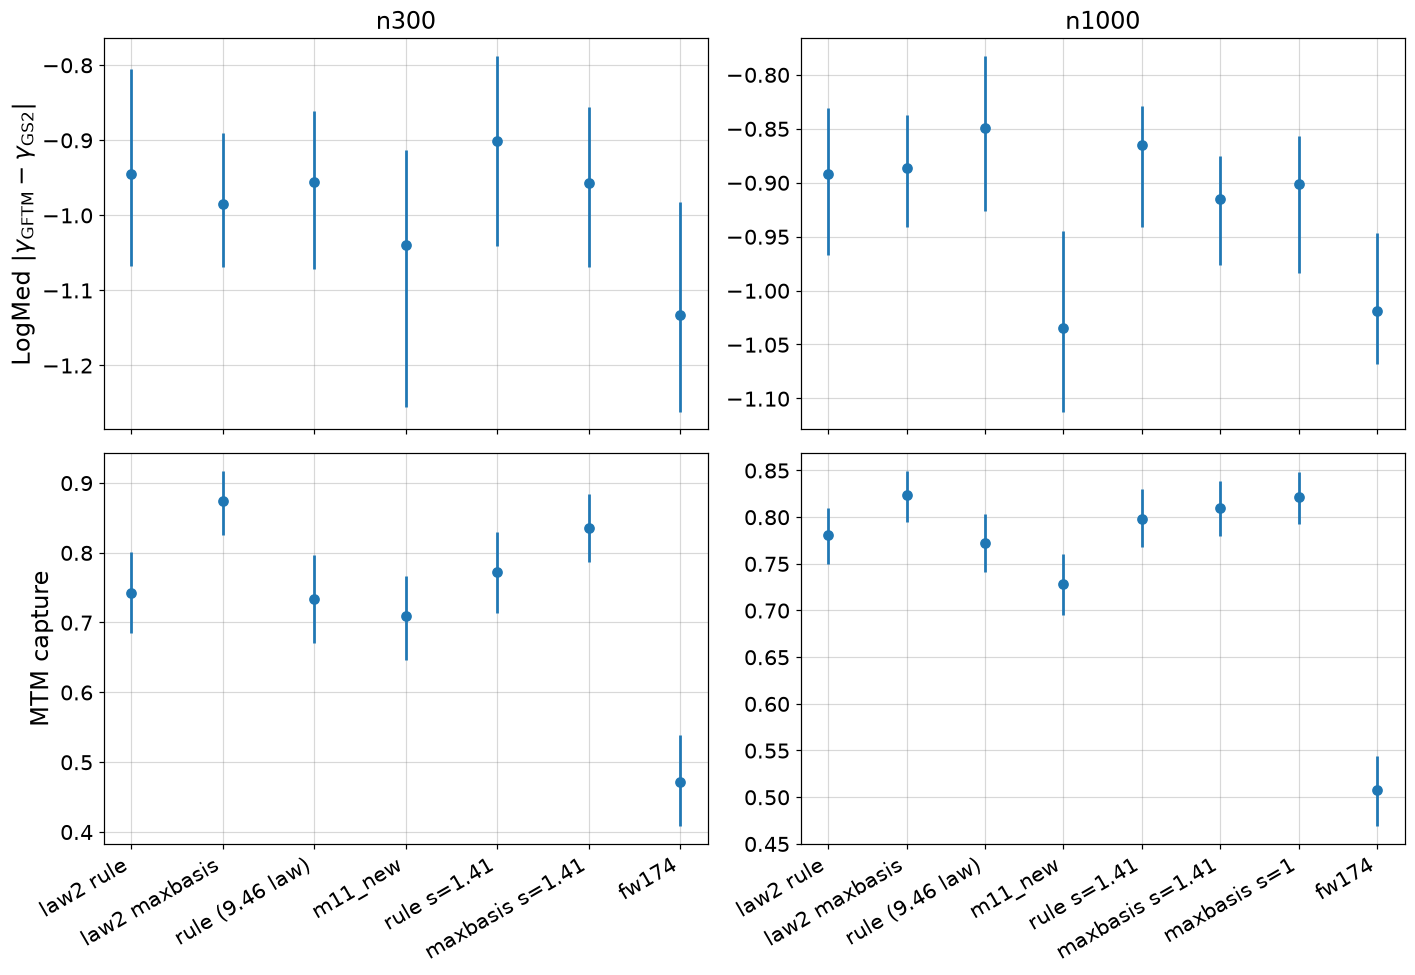

In [6]:
plot_dir = ROOT / "Plots" / analysis_name
plot_dir.mkdir(parents=True, exist_ok=True)
fig1, axes = plt.subplots(2, 2, figsize=(13, 9), sharex="col")
for col, dname in enumerate(("n300", "n1000")):
    arms, table = draws[dname][1], table_paired[dname]
    positions = np.arange(len(arms))
    logmed = np.log10([table[arm]["medae"] for arm in arms])
    axes[0, col].errorbar(positions, logmed, yerr=np.abs(np.log10([table[arm]["ae_ci"] for arm in arms]).T - logmed), ls="", marker="o")
    axes[1, col].errorbar(positions, [table[arm]["capture"] for arm in arms],
                      yerr=np.abs(np.array([table[arm]["cap_ci"] for arm in arms]).T - [table[arm]["capture"] for arm in arms]), ls="", marker="o")
    axes[0, col].set_title(dname)
    axes[1, col].set_xticks(positions, arms, rotation=30, ha="right")
axes[0, 0].set_ylabel(r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$")
axes[1, 0].set_ylabel("MTM capture")
fig1.tight_layout()
plt.show()

/tmp/ipykernel_140489/972907615.py:17: UserWarning: The figure layout has changed to tight
  fig2.tight_layout()


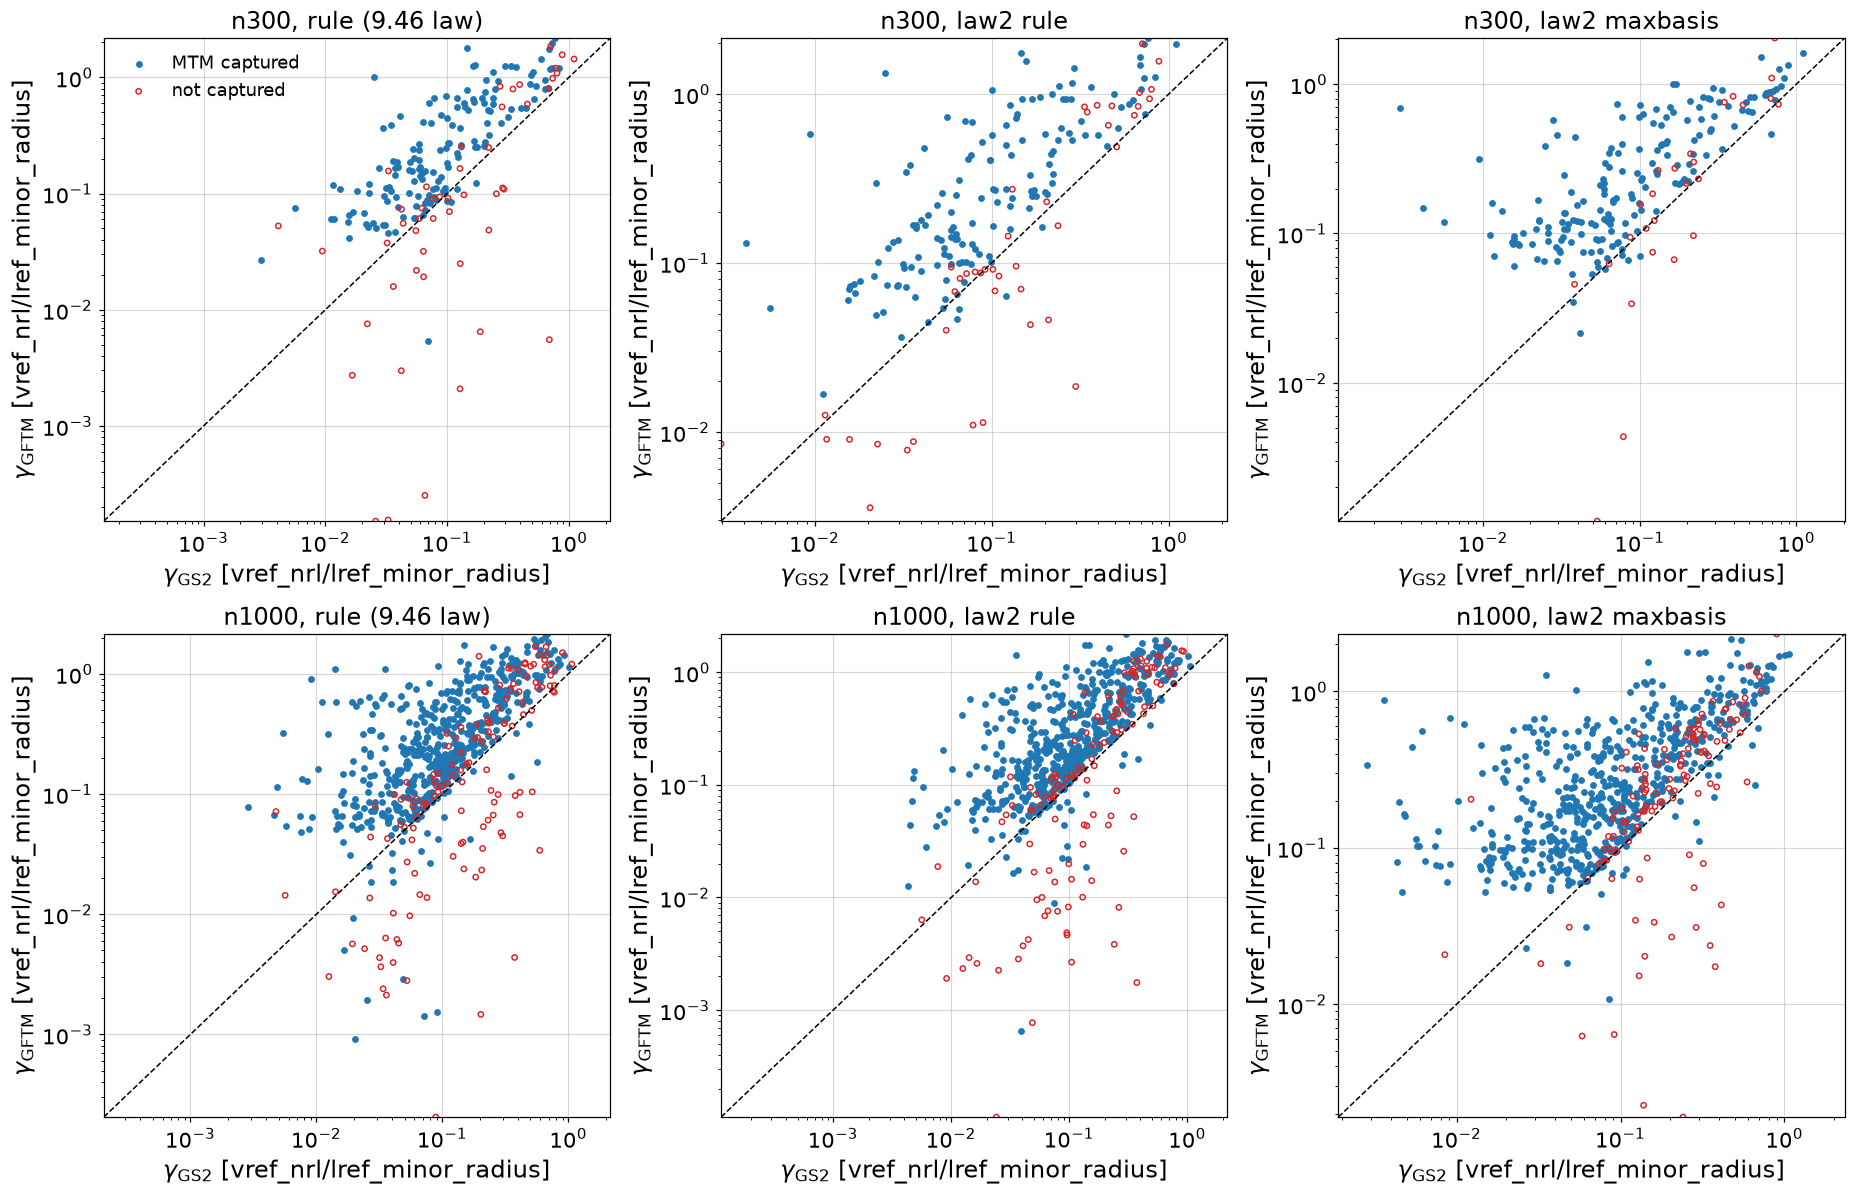

In [7]:
fig2, axes = plt.subplots(2, 3, figsize=(17, 11))
for row, dname in enumerate(("n300", "n1000")):
    draw_result = results[dname]
    paired_mask = draw_result["mtm"] & np.logical_and.reduce([draw_result["arm"][arm]["have"] for arm in draws[dname][1]])
    gamma_gs2_paired = draw_result["gamma_gs2"][paired_mask]
    for col, arm in enumerate((OLD, NEW, NEWMB)):
        arm_result = draw_result["arm"][arm]
        gamma_gftm, captured = arm_result["gamma"][paired_mask], arm_result["mtm_mode"][paired_mask]
        positive = gamma_gftm > 0
        axes[row, col].scatter(gamma_gs2_paired[positive & captured], gamma_gftm[positive & captured], s=12, label="MTM captured")
        axes[row, col].scatter(gamma_gs2_paired[positive & ~captured], gamma_gftm[positive & ~captured], s=12, facecolors="none", edgecolors="C3", label="not captured")
        limits = [min(gamma_gs2_paired.min(), gamma_gftm[positive].min()), max(gamma_gs2_paired.max(), gamma_gftm[positive].max())]
        axes[row, col].plot(limits, limits, "k--", lw=1)
        axes[row, col].set(xscale="log", yscale="log", xlim=limits, ylim=limits, title=f"{dname}, {arm}",
                     xlabel=rf"$\gamma_{{\rm GS2}}$ [{draw_result['unit']}]", ylabel=rf"$\gamma_{{\rm GFTM}}$ [{draw_result['unit']}]")
axes[0, 0].legend()
fig2.tight_layout()
plt.show()

## Save

In [8]:
fig1.savefig(plot_dir / "fig1_logmed_capture_paired.png")
fig2.savefig(plot_dir / "fig2_gamma_scatter_old_vs_new_law.png")

## Interpretation

_Written after the executed run; see the Fusion_PhD README `results/mtm_extent_rule_law2/README.md`._